# CRM Reactivation Methodology
## Goal

The objective is to identify the customers with the highest probability of being reactivated after a long inactivity period.

In business terms, the company wants to answer this question:

> Among the customers who have already stopped buying for at least 2 years, which ones are the best targets for a reactivation campaign?

In [76]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

importing data

In [115]:
client_df = pd.read_csv("../TOOL_CLIENT.csv")
sales_df = pd.read_csv("../TOOL_SALES.csv")

initial_number_of_sales = len(sales_df)
initial_number_of_clients = len(client_df)

#  Dealing with datatypes

In [94]:
print(client_df.dtypes)
print(sales_df.dtypes)

CLIENT_ID               int64
CLIENT_CREATE DATE        str
REGION                    str
TRADE SECTOR            int64
N_EMPLOYEES             int64
ECONOMIC_POT          float64
ECO_POT_CLASS             str
RISK_CAT                  str
dtype: object
YYYYMM             int64
ITEM_ID            int64
FLG_TOOL           int64
SALES_CHANNEL        str
NET              float64
UNIT                 str
FAMILY_CODE          str
GROUP_CODE           str
CLIENT_ID          int64
CANCELLED            str
dtype: object


# Data cleaning
and data types adjustments

## in CLIENT_TOOL:


| COLUMN | TYPE | | TURN INTO |
|---|---|---|---|
| **CLIENT_ID** | int64 | -> | ok |
| **CLIENT_CREATE DATE** | object |-> | datetime64[ns] |
| **REGION** | object |-> | string |
| **TRADE SECTOR** |  int64  |-> |  ok|
| **N_EMPLOYEES** | int64 |-> |ok |
| **ECONOMIC_POT** | float64 |-> |  ok |
| **ECO_POT_CLASS** | object |-> | string |
| **RISK_CAT** | object |-> | string |



In [116]:
client_df["CLIENT_CREATE DATE"] = pd.to_datetime(client_df["CLIENT_CREATE DATE"])
client_df["REGION"]             = client_df["REGION"].astype("string")
#cambia raggruppando le regioni in macroaree
client_df["REGION"]             = client_df["REGION"].fillna("unknown")
client_df["REGION"]             = client_df["REGION"].astype("string")
client_df["ECO_POT_CLASS"]      = client_df["ECO_POT_CLASS"].astype("string")
client_df["RISK_CAT"]           = client_df["RISK_CAT"].astype("string")
# display(client_df.dtypes)
# display(client_df)


## In Sales:

| COLUMN | TYPE | | TURN INTO |
|---|---|---|---|
| **YYYYMM** | int64 | -> | datetime64[ns] |
| **ITEM_ID** | int64 | -> | ok |
| **FLG_TOOL** | int64 | -> | ok |
| **SALES_CHANNEL** | object |-> |  string |
| **NET** | float64 |-> | ok |
| **UNIT** |  object  |-> |  string|
| **FAMILY_CODE** | object |-> |string |
| **GROUP_CODE** | object |-> |  string |
| **CLIENT_ID** | int64 |-> | OK |
| **CANCELLED** | object |-> | string |

In [ ]:
sales_df["UNIT"] = sales_df["UNIT"].astype("string")
sales_df["FAMILY_CODE"] = sales_df["FAMILY_CODE"].astype("string")
sales_df["YYYYMM"] = pd.to_datetime(sales_df["YYYYMM"], format="%Y%m")
sales_df["SALES_CHANNEL"] = sales_df["SALES_CHANNEL"].astype("string")
sales_df['CANCELLED'] = (sales_df['CANCELLED'] == 'X').astype(int)


## Inspecting transactions

Transactions with negative values (not standalone) could provide usefull informations about a client.  So we create another column NNeT  which contains these transactions, and we tear them apart from the original NeT column which now contains only positive ones.

In [118]:
#Now NNET contains the negative values of NET, while NET contains the non-negative values. This way we can keep track of both sales and returns in separate columns.
sales_df.loc[sales_df['NET'] < 0, 'NNET'] = sales_df['NET']
sales_df['NNET'] = sales_df['NNET'].where(sales_df['NNET'] <= 0, np.nan)  #NeW COLUMN!
sales_df['NET'] = sales_df['NET'].where(sales_df['NET'] >= 0, np.nan) 
transactions_with_negative_values = len(sales_df[sales_df['NNET'] < 0])


Standalone transactions are not usefull. So, we remove these transactions.

In [119]:
df_unique = sales_df[~sales_df["CLIENT_ID"].duplicated(keep=False)]
clients_who_made_1_transaction = set(df_unique["CLIENT_ID"])

In [120]:

print(f"Dimension of sales before filtering: {len(sales_df) }")
sales_df = sales_df[~sales_df['CLIENT_ID'].isin(clients_who_made_1_transaction)]
client_df = client_df[~client_df['CLIENT_ID'].isin(clients_who_made_1_transaction)]
print(f"Dimension of sales after filtering: {len(sales_df) }")

Dimension of sales before filtering: 2050449
Dimension of sales after filtering: 2037299


More about standalone transactions: we also should remove clients who made more than one transaction, BUT on a single day, and then disappeared. 

In [121]:
daily_counts = (
    sales_df.groupby(['CLIENT_ID', 'YYYYMM'])
    .size()
    .reset_index(name='n_days_purchase')
)
daily_counts

days_per_client = (
    sales_df.groupby('CLIENT_ID')['YYYYMM']
    .nunique()
    .reset_index(name='n_days')
)

multi_same_day = (
    daily_counts.groupby('CLIENT_ID')['n_days_purchase']
    .max()
    .reset_index(name='max_same_day_purchases')
)
# print(days_per_client)
# print(multi_same_day)
single_day_purchase_clients = (
    days_per_client.merge(multi_same_day, on='CLIENT_ID')
)


single_day_purchase_clients = single_day_purchase_clients[
    (single_day_purchase_clients['n_days'] == 1) &
    (single_day_purchase_clients['max_same_day_purchases'] > 1)
]['CLIENT_ID']

print(len(sales_df))
sales_df = sales_df[~sales_df['CLIENT_ID'].isin(single_day_purchase_clients)]
print(len(sales_df))
client_df = client_df[~client_df['CLIENT_ID'].isin(single_day_purchase_clients)]

2037299
1931363


In [122]:
to_display = pd.DataFrame([
    {
        "Transactions with negative values:": len(sales_df[sales_df['NNET'] < 0]),
        "Total N° transactions": initial_number_of_sales,
        "Percentage": ((len(sales_df[sales_df['NNET'] < 0])) / initial_number_of_sales * 100)
    }])
to_display1 = pd.DataFrame([
    {
        "N° of clints of \"standalone\" transactions:": len(clients_who_made_1_transaction),
        "Total N° of clients": initial_number_of_clients,
        "Percentage": len(clients_who_made_1_transaction) / initial_number_of_sales*100,
    }])
to_display2 = pd.DataFrame([
    {
        "N° of single-day-purchase clients:": len(single_day_purchase_clients),
        "Total N° of clients": initial_number_of_clients,
        "Percentage": len(single_day_purchase_clients)/ initial_number_of_clients*100,
    }
    
])

display(to_display)
display(to_display1)
display(to_display2)

,Transactions with negative values:,Total N° transactions,Percentage
0,2192,2050449,0.106903


,"N° of clints of ""standalone"" transactions:",Total N° of clients,Percentage
0,13150,93257,0.641323


,N° of single-day-purchase clients:,Total N° of clients,Percentage
0,20893,93257,22.40368


# Dates

This part is critical, and yet to be defined.
In this notebook we consider these time windows:

|----------2017---------|------2018------|--------2019-------|----2020-----|-----2021-----|

|-feature time window-|------observing inactivity window--|----come-back window-----|

In [123]:
feature_start = pd.Timestamp("2017-01-01")
feature_end = pd.Timestamp("2017-12-31")

cutoff_date = pd.Timestamp("2019-12-31")

min_registration_date = pd.Timestamp("2016-12-31")

outcome_start = pd.Timestamp("2020-01-01")
outcome_end = pd.Timestamp("2021-12-31")

# Inspecting clients


 

In [124]:
clients_after_filtering = sales_df['CLIENT_ID'].unique()

total_clients = len(clients_after_filtering)
print(f"Total useful clients: {total_clients} out of {initial_number_of_clients} that is {total_clients/initial_number_of_clients*100:.2f}%")

Total useful clients: 59214 out of 93257 that is 63.50%


Removing clients

In [125]:
#clients active in  2017. From this set of clients, we will have to exclude those who are active in 2018-2019, as they are not part of the inactive pool, and we will check if they reactivate in 2020-2021
#to obatin those that could potentially reactivate, we have to consider only those clients that were active in 2017, as those are the only ones that could potentially reactivate in 2020-2021 
clients_active_feature_time_window = set(
    sales_df.loc[ sales_df["YYYYMM"].between(feature_start, feature_end), "CLIENT_ID" ].unique()
)

# These clients have been inactive during 2018 and 2019, so they are part of the inactive pool, and we will check if they reactivate in 2020-2021
clients_active_2018_2019 = set(
    sales_df.loc[ sales_df["YYYYMM"].between(feature_end, outcome_start), "CLIENT_ID" ].unique()
)

clients_inactive_2018_2019_but_activ_in_2017 = clients_active_feature_time_window - clients_active_2018_2019

# 5) clients that reactivated in 2020-2021, we will check how many of the clients that were inactive in 2018-2019, but active in 2017, reactivated in 2020-2021, and we will check if they are part of the final set of clients that we will use for the model, as they are the only ones that could potentially reactivate in 2020-2021
clients_activ_2020_2021 = set(
    sales_df.loc[sales_df["YYYYMM"].between(outcome_start, outcome_end),"CLIENT_ID"].unique()
)

#we have to subtract clients which are not in the final set, as they are not part of the inactive pool 
clients_reactivated_2020_2021 = clients_inactive_2018_2019_but_activ_in_2017.intersection(clients_activ_2020_2021)

print(f"Clients reactivated in 2020-2021: {len(clients_reactivated_2020_2021)} which is {len(clients_reactivated_2020_2021)/total_clients*100:.2f}% of the total clients, and {len(clients_reactivated_2020_2021)/len(clients_inactive_2018_2019_but_activ_in_2017)*100:.2f}% of those inactive in 2018-2019.")


Clients reactivated in 2020-2021: 2835 which is 4.79% of the total clients, and 47.50% of those inactive in 2018-2019.


# Visualizing groups of clients

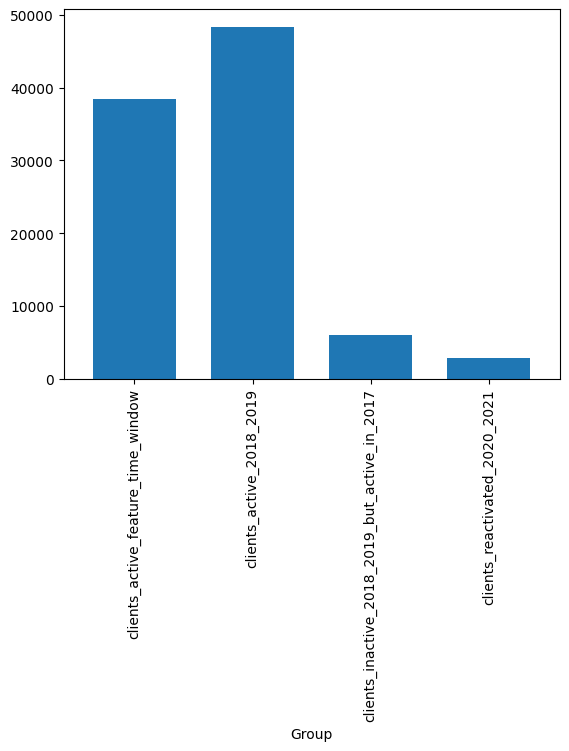

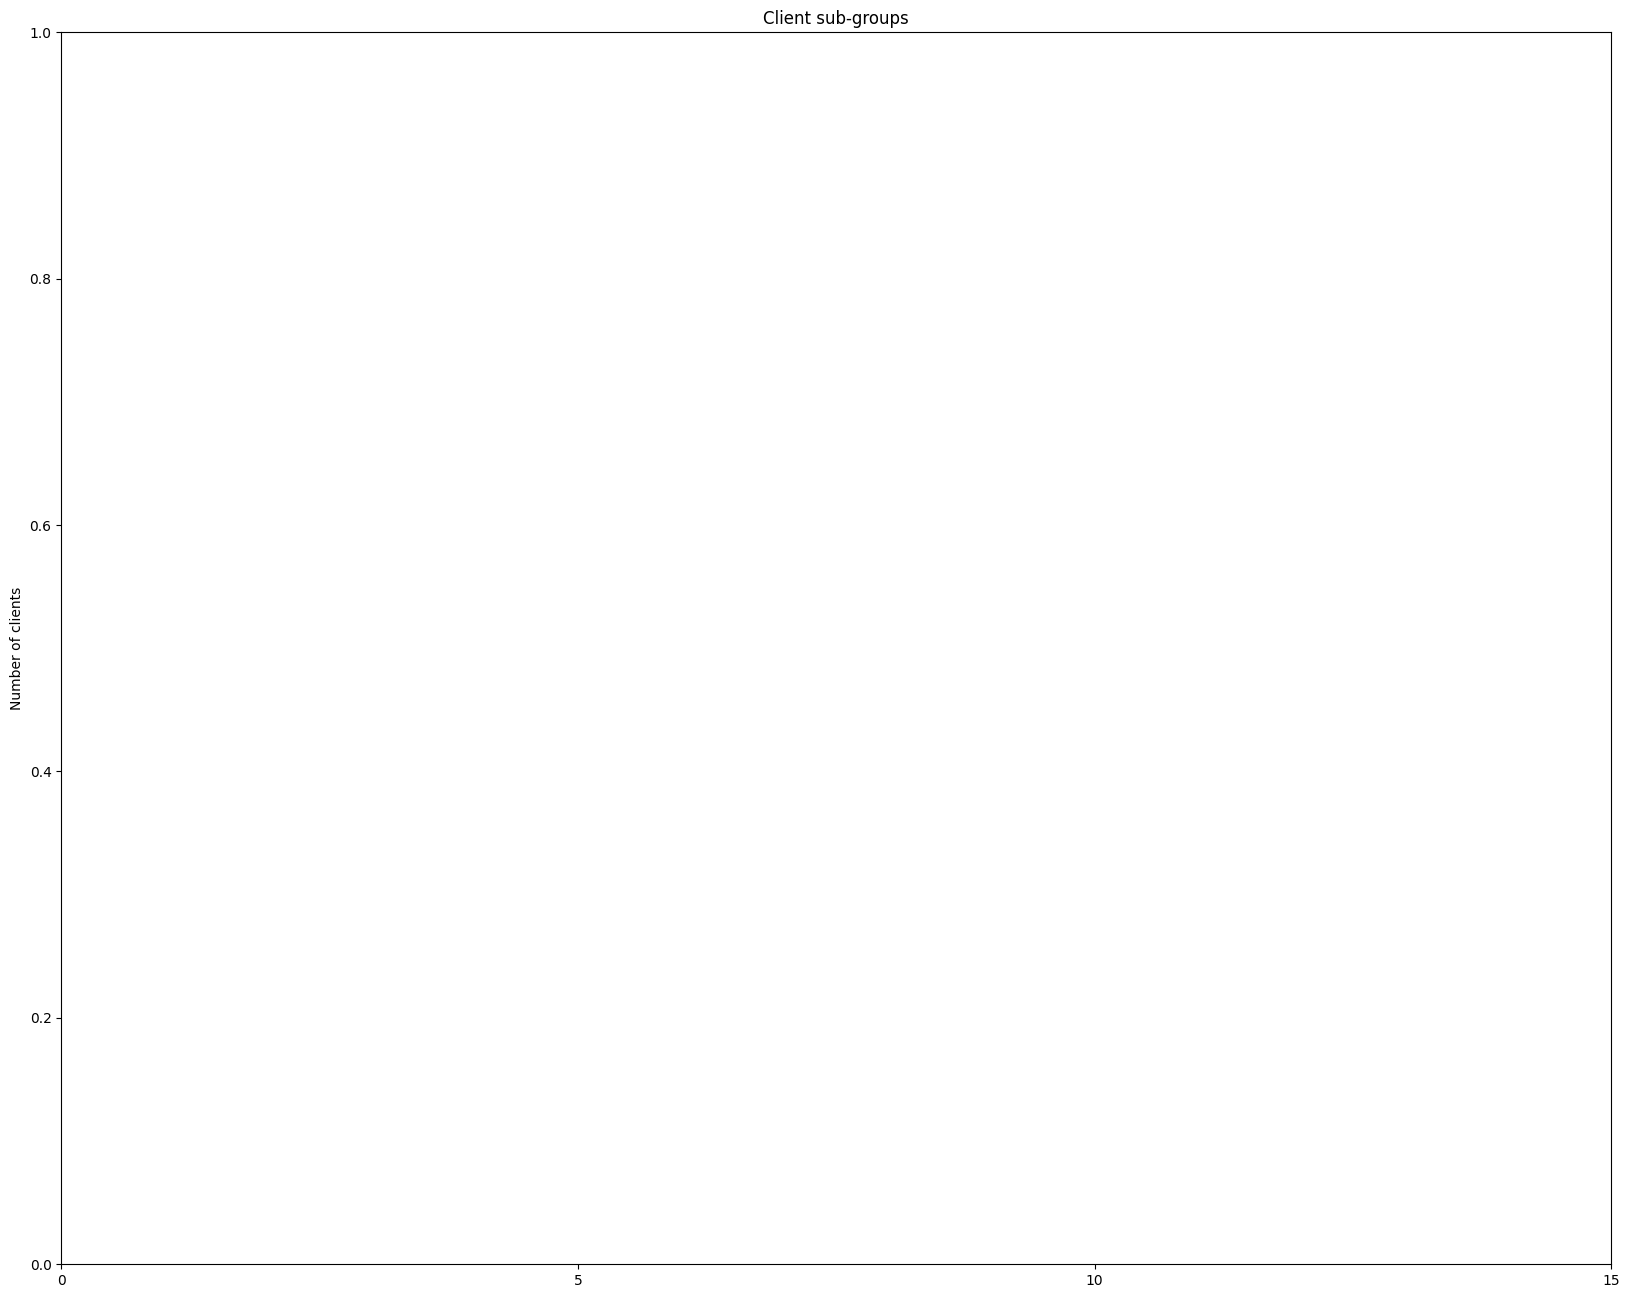

In [135]:
import matplotlib.pyplot as plt

counts = pd.Series({
    "clients_active_feature_time_window": len(clients_active_feature_time_window),
    "clients_active_2018_2019": len(clients_active_2018_2019),
    "clients_inactive_2018_2019_but_active_in_2017": len(clients_inactive_2018_2019_but_activ_in_2017),
    "clients_reactivated_2020_2021": len(clients_reactivated_2020_2021)
})

counts.plot(kind='bar', width=0.7)
plt.xlabel('Group')
plt.figure(figsize=(20, 16))
plt.ylabel('Number of clients')
plt.title('Client sub-groups')
position = [0,5,10,15]
plt.xticks(position, rotation=0)
plt.show()

Creating new dataframes to use from now on with only valid clients.

In [ ]:
new_client_df = client_df[client_df["CLIENT_ID"].isin(clients_inactive_2018_2019_but_activ_in_2017)]
new_sales_df = sales_df[sales_df["CLIENT_ID"].isin(clients_inactive_2018_2019_but_activ_in_2017)]
model_df = new_client_df


creating the target and  getting the reactivation rate 

In [60]:
new_client_df["target"] = new_client_df["CLIENT_ID"].isin(clients_reactivated_2020_2021).astype(int)

print(f"{(new_client_df['target'] == 1).sum()/len(new_client_df)*100:.2f}% of the clients reactivated in 2020-2021")

47.50% of the clients reactivated in 2020-2021


# Features engineering


In [61]:

model_df["client_age_months"] = (
    (cutoff_date.year - model_df["CLIENT_CREATE DATE"].dt.year) * 12
    + (cutoff_date.month - model_df["CLIENT_CREATE DATE"].dt.month)
)

Features that can be derived from transactions:

In [62]:
#Features that can be derived from transactions:
total_per_cust      = new_sales_df.groupby("CLIENT_ID")["NET"].sum()
tnsx_per_cust       = new_sales_df.groupby("CLIENT_ID")["NET"].count()
mean_spent_per_cust = new_sales_df.groupby("CLIENT_ID")["NET"].mean()
model_df["total_amount"]        = model_df["CLIENT_ID"].map(total_per_cust)
model_df["tsnx_p_cust"]         = model_df["CLIENT_ID"].map(tnsx_per_cust)
model_df["mean_spent_per_cust"] = model_df["CLIENT_ID"].map(mean_spent_per_cust)

In [63]:
model_df

,CLIENT_ID,CLIENT_CREATE DATE,REGION,TRADE SECTOR,N_EMPLOYEES,ECONOMIC_POT,ECO_POT_CLASS,RISK_CAT,target,client_age_months,total_amount,tsnx_p_cust,mean_spent_per_cust
0,9306,2005-11-15,BZ,11000,6,8659.81,D,3d,1,169,2920.17,4,730.042500
6,11767,2005-11-15,BL,22100,1,2264.23,E,3d,0,169,1266.84,3,422.280000
45,1775,2005-11-15,FE,22100,2,4528.46,E,3d,1,169,524.11,9,58.234444
70,6672,2005-11-15,BO,22100,1,2264.23,E,T8,1,169,4024.11,31,129.810000
79,1465,2005-11-15,LT,11000,2,3019.02,E,3a,1,169,1405.39,5,281.078000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71776,71778,2017-12-19,PG,15100,3,4571.88,E,5d,1,24,95.22,3,31.740000
71789,71797,2017-12-20,PN,15400,3,1483.35,E,5a,1,24,1452.02,9,161.335556
71794,71800,2017-12-20,TE,22100,2,4528.46,E,5a,1,24,1967.30,9,218.588889
71818,71810,2017-12-21,PC,22100,1,2264.23,E,3a,1,24,3783.95,44,85.998864


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [65]:
X = model_df.copy()
X.drop(columns=["target","CLIENT_ID"], inplace=True)
y = model_df["target"].copy()


In [66]:
# columns with string/object data
categorical_features = model_df.select_dtypes(include=[ 'string']).columns.tolist()

# columns with numeric data: int64 and float64
numeric_features = model_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove("CLIENT_ID")  
numeric_features.remove("target")  


In [67]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [68]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# print("X_train:", X_train.shape)
# print("X_test:", X_test.shape)
# print("Train target mean:", y_train.mean())
# print("Test target mean:", y_test.mean())

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

AUC: 0.8148738850493237

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.95      0.81       627
           1       0.91      0.56      0.69       567

    accuracy                           0.76      1194
   macro avg       0.81      0.75      0.75      1194
weighted avg       0.80      0.76      0.75      1194

Confusion matrix:
[[595  32]
 [252 315]]


In [39]:
# Get transformed feature names from the fitted preprocessor
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefs = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs),
    "odds_ratio": np.exp(coefs)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

,feature,coefficient,abs_coefficient,odds_ratio
134,cat__RISK_CAT_4d,-1.767889,1.767889,0.170693
135,cat__RISK_CAT_5a,1.454958,1.454958,4.284304
136,cat__RISK_CAT_5b,1.297057,1.297057,3.658514
137,cat__RISK_CAT_5c,1.134937,1.134937,3.110977
139,cat__RISK_CAT_T8,-0.983552,0.983552,0.373980
122,cat__RISK_CAT_1d,-0.898311,0.898311,0.407257
130,cat__RISK_CAT_3d,-0.811215,0.811215,0.444318
126,cat__RISK_CAT_2d,0.751117,0.751117,2.119366
138,cat__RISK_CAT_5d,-0.743166,0.743166,0.475606
9,cat__REGION_AN,-0.629197,0.629197,0.533020


# Boosted tree model

In [ ]:
from sklearn.ensemble import RandomForestClassifier


clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(max_depth=10, random_state=42))
])

clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))